# MFCC-based Speaker Recognition — Float Model Training (BRAM-Opt v2)

Loads pre-generated MFCC dataset splits from `MFCC_datasets/` and trains the compact
**BRAM-Opt v2** float CNN for speaker recognition on NBFM IQ signals.

## Architecture

All layers ≤576 parameters. Input shape: `(20, 64, 2)`.

```
Input  (20, 64, 2)
  ├─ Conv2D(8, 3×3, same)   3×3×2×8 =  144 params   → (20, 64, 8)
  ├─ BN + ReLU
  ├─ MaxPool(2, 2)                                   → (10, 32, 8)
  ├─ Conv2D(8, 3×3, same)   3×3×8×8 =  576 params   → (10, 32, 8)
  ├─ BN + ReLU
  ├─ MaxPool(2, 4)                                   → ( 5,  8, 8)
  ├─ Conv2D(8, 3×3, same)   3×3×8×8 =  576 params   → ( 5,  8, 8)
  ├─ BN + ReLU
  ├─ MaxPool(5, 4)                                   → ( 1,  2, 8)
  ├─ Flatten                                         → 16
  ├─ Dense(16)               16×16  =  256 params
  └─ Dense(NUM_CLASSES)      16×N   =  ~160 params
```

## Training Strategy

- **Optimizer:** Adam, LR = 1e-3
- **Scheduler:** ReduceLROnPlateau (factor=0.5, patience=10, min_lr=1e-6)
- **Early stopping:** patience=20, restores best weights
- **Max epochs:** 150
- **Checkpoint caching:** skips training if `.h5` file exists

---
## Imports

In [13]:
import os, json, pickle, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 55
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Training hyperparameters
MAX_EPOCHS    = 150
LEARNING_RATE = 1e-3
PATIENCE      = 20

print('TF:', tf.__version__)
print('Device:', 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU')

TF: 2.21.0
Device: CPU


---
## Load Dataset from MFCC_datasets/

The dataset must be generated by `MFCC_dataset_generation.ipynb` with `hop_length=2250`,
producing `MFCC_FRAMES=64`.

In [14]:
DATASETS_PATH = 'MFCC_datasets'
METADATA_PATH = os.path.join(DATASETS_PATH, 'metadata.json')

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata['MFCC_input_shape'])
    NUM_CLASSES      = metadata['num_classes']
    N_MFCC           = metadata.get('N_MFCC', 20)
    MFCC_FRAMES      = metadata.get('MFCC_FRAMES')
    HOP_LENGTH       = metadata.get('HOP_LENGTH', 2250)
    N_FFT            = metadata.get('N_FFT', 2048)
    SAMPLING_FREQ    = metadata.get('SAMPLING_FREQ', 48000)
    batch_size       = metadata.get('batch_size', 32)
    subfolders       = metadata.get('subfolders', [])
    unique_labels    = metadata.get('labels', [])
    print('Metadata loaded from metadata.json')
else:
    raise FileNotFoundError(
        'metadata.json not found in MFCC_datasets/ -- '
        'run MFCC_dataset_generation.ipynb first.'
    )

# Verify BRAM-Opt v2 compatibility
assert MFCC_FRAMES == 64 and HOP_LENGTH == 2250, (
    f'\n[ERROR] Dataset incompatible with BRAM-Opt v2 architecture:\n'
    f'  MFCC_FRAMES = {MFCC_FRAMES}  (expected: 64)\n'
    f'  HOP_LENGTH  = {HOP_LENGTH}  (expected: 2250)\n'
    'Solution: run MFCC_dataset_generation.ipynb with hop_length=2250.'
)

print(f'  MFCC input shape : {MFCC_input_shape}')
print(f'  Num classes      : {NUM_CLASSES}')
print(f'  N_MFCC           : {N_MFCC}')
print(f'  MFCC_FRAMES      : {MFCC_FRAMES}  '
      f'(hop={HOP_LENGTH} => {HOP_LENGTH/SAMPLING_FREQ*1000:.1f} ms/frame)')
print(f'  Sampling freq    : {SAMPLING_FREQ} Hz')
print(f'  Classes          : {subfolders}')
print('\n[OK] Dataset BRAM-Opt v2 verified (MFCC_FRAMES=64, hop_length=2250)')

Metadata loaded from metadata.json
  MFCC input shape : (20, 64, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 64  (hop=2250 => 46.9 ms/frame)
  Sampling freq    : 48000 Hz
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']

[OK] Dataset BRAM-Opt v2 verified (MFCC_FRAMES=64, hop_length=2250)


In [15]:
# Load batched TF datasets
SPEC_PATH = os.path.join(DATASETS_PATH, 'element_spec.pkl')
with open(SPEC_PATH, 'rb') as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'train_batches'),
    element_spec=specs['train']
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'validation_batches'),
    element_spec=specs['validation']
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_test_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'test_batches'),
    element_spec=specs['test']
).prefetch(tf.data.AUTOTUNE)

for bX, by in MFCC_dataset_train_batches.take(1):
    print(f'Train batch: X={bX.shape}, y={by.shape}')
print('Datasets loaded.')

Train batch: X=(32, 20, 64, 2), y=(32,)
Datasets loaded.


---
## CNN Model Definition — BRAM-Opt v2

All convolutional layers use only **8 filters** to stay within the 576-parameter limit
required for `Strategy='Latency'` with `ReuseFactor=1` in FPGA synthesis.

In [16]:
def build_compact_float_model(input_shape, n_classes):
    """
    CNN BRAM-Opt v2 -- all layers <= 576 parameters.
    Designed for input shape (20, 64, 2).

    Spatial reduction MFCC (20, 64):
      MaxPool(2, 2)  ->  (10, 32)
      MaxPool(2, 4)  ->  ( 5,  8)
      MaxPool(5, 4)  ->  ( 1,  2)  ->  Flatten: 1x2x8 = 16
    """
    model = Sequential([
        InputLayer(input_shape),
        # -- Block 1: (20, 64, 2) -> (10, 32, 8) --
        Conv2D(8, (3, 3), padding='same', name='conv1'),   # 144 params
        BatchNormalization(name='bn1'),
        Activation('relu', name='act1'),
        MaxPooling2D((2, 2), name='pool1'),
        # -- Block 2: (10, 32, 8) -> (5, 8, 8) --
        Conv2D(8, (3, 3), padding='same', name='conv2'),   # 576 params
        BatchNormalization(name='bn2'),
        Activation('relu', name='act2'),
        MaxPooling2D((2, 4), name='pool2'),
        # -- Block 3: (5, 8, 8) -> (1, 2, 8) --
        Conv2D(8, (3, 3), padding='same', name='conv3'),   # 576 params
        BatchNormalization(name='bn3'),
        Activation('relu', name='act3'),
        MaxPooling2D((5, 4), name='pool3'),
        # -- Classifier: 16 -> 16 -> n_classes --
        Flatten(name='flatten'),
        Dense(16, name='dense1'),                          # 256 params
        Activation('relu', name='act4'),
        Dropout(0.3, name='dropout'),
        Dense(n_classes, name='output'),                   # 160 params (N=10)
        Activation('softmax', name='softmax'),
    ], name='Compact_CNN_Float_v2')
    return model


def verify_layer_sizes(model, max_elements=4096):
    """Verifies that each layer's weights have <= max_elements elements."""
    print(f'\nVerifying layer sizes (limit: {max_elements})')
    print('-' * 68)
    all_ok = True
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w = weights[0]
        n = int(np.prod(w.shape))
        ok = n <= max_elements
        status = 'OK' if ok else 'EXCEEDS'
        if not ok:
            all_ok = False
        print(f'  {status:10s} {layer.name:20s}: {n:7d} elements | shape {w.shape}')
    print('-' * 68)
    if all_ok:
        print('[OK] All layers <= 4096 elements')
    else:
        print('[WARN] Some layers exceed limit')
    return all_ok

print('Model builder defined.')

Model builder defined.


---
## Train the Compact Float Model

If a saved checkpoint exists it is loaded directly.
If not, the model is trained from scratch with:

- **Adam** with `LR=1e-3` + **ReduceLROnPlateau** (factor=0.5, patience=10, min_lr=1e-6)
- **EarlyStopping** (patience=20, restores best weights)
- **Max epochs:** 150
- Checkpoint saved as `.h5` for compatibility with downstream workflows

In [17]:
COMPACT_CKPT_DIR  = './ckpt_compact_float'
COMPACT_CKPT_PATH = f'{COMPACT_CKPT_DIR}/compact_float_best.h5'
COMPACT_HIST_PATH = f'{COMPACT_CKPT_DIR}/compact_float_history.json'
os.makedirs(COMPACT_CKPT_DIR, exist_ok=True)

if os.path.exists(COMPACT_CKPT_PATH):
    print(f'Loading model from: {COMPACT_CKPT_PATH}')
    model_compact_float = tf.keras.models.load_model(COMPACT_CKPT_PATH)
    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print('Training model from scratch...')
    model_compact_float = build_compact_float_model(MFCC_input_shape, NUM_CLASSES)
    model_compact_float.summary()

    verify_layer_sizes(model_compact_float)

    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_float = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            verbose=1,
            min_lr=1e-6
        )
    ]

    history_float = model_compact_float.fit(
        MFCC_dataset_train_batches,
        epochs=MAX_EPOCHS,
        validation_data=MFCC_dataset_validation_batches,
        callbacks=callbacks_float
    )

    # Save model in H5 format
    model_compact_float.save(COMPACT_CKPT_PATH, save_format='h5')
    print(f'Model saved -> {COMPACT_CKPT_PATH}')

    # Save training history
    hist_dict = {k: [float(v) for v in vals]
                 for k, vals in history_float.history.items()}
    with open(COMPACT_HIST_PATH, 'w') as f:
        json.dump(hist_dict, f, indent=2)
    print(f'History saved -> {COMPACT_HIST_PATH}')

Training model from scratch...


Model: "Compact_CNN_Float_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 20, 64, 8)      │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 20, 64, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (Activation)               │ (None, 20, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 10, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 10, 32, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (Activation)               │ (None, 10, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 5, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 5, 8, 8)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3 (Activation)               │ (None, 5, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 1, 2, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act4 (Activation)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,858 (7.26 KB)

 Trainable params: 1,810 (7.07 KB)

 Non-trainable params: 48 (192.00 B)


Verifying layer sizes (limit: 4096)
--------------------------------------------------------------------
  OK         conv1               :     144 elements | shape (3, 3, 2, 8)
  OK         bn1                 :       8 elements | shape (8,)
  OK         conv2               :     576 elements | shape (3, 3, 8, 8)
  OK         bn2                 :       8 elements | shape (8,)
  OK         conv3               :     576 elements | shape (3, 3, 8, 8)
  OK         bn3                 :       8 elements | shape (8,)
  OK         dense1              :     256 elements | shape (16, 16)
  OK         output              :     160 elements | shape (16, 10)
--------------------------------------------------------------------
[OK] All layers <= 4096 elements
Epoch 1/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1584 - loss: 2.3971 - val_accuracy: 0.2378 - val_loss: 2.2247 - learning_rate: 0.0010
Epoch 2/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2180 - loss: 2.1563 - v

Model saved -> ./ckpt_compact_float/compact_float_best.h5
History saved -> ./ckpt_compact_float/compact_float_history.json


### Training History

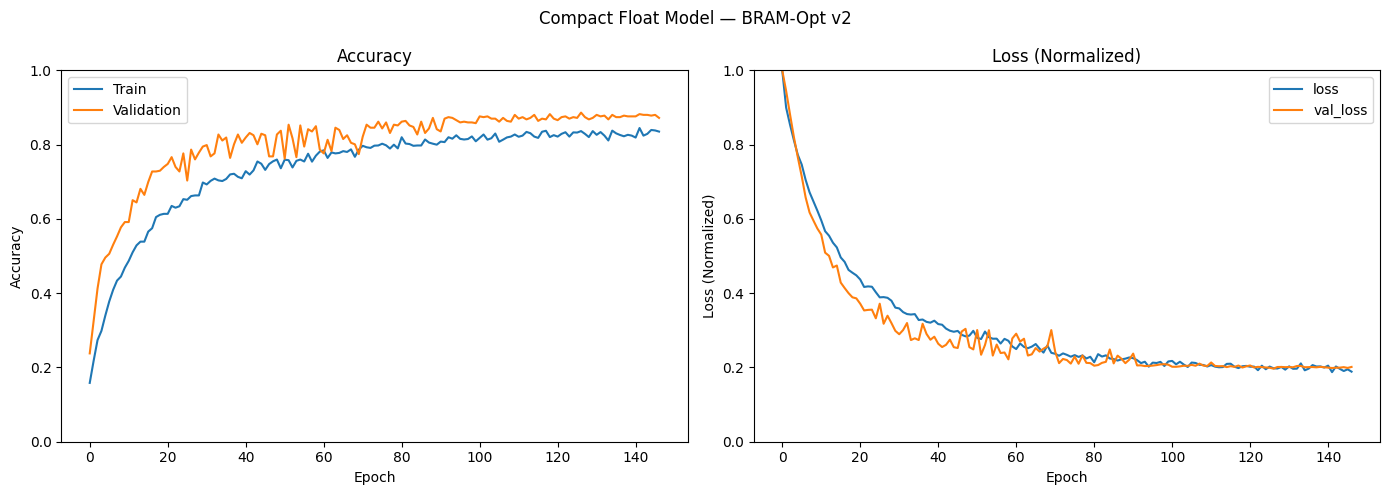

In [18]:
# Plot training history
if os.path.exists(COMPACT_HIST_PATH):
    with open(COMPACT_HIST_PATH) as f:
        hist = json.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist.get('accuracy', []), label='Train')
    axes[0].plot(hist.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()

    for key in ['loss', 'val_loss']:
        vals = hist.get(key, [])
        if vals:
            mx = max(vals) or 1.0
            axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Loss (Normalized)',
                title='Loss (Normalized)', ylim=[0, 1])
    axes[1].legend()

    plt.suptitle('Compact Float Model — BRAM-Opt v2')
    plt.tight_layout()
    plt.show()
else:
    print('No history file found.')

---
## Model Evaluation on Validation and Test Sets

In [19]:
print('Float model — Validation set:')
val_loss, val_acc = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=1
)
print(f'  Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}')

print('\nFloat model — Test set:')
test_loss, test_acc = model_compact_float.evaluate(
    MFCC_dataset_test_batches, verbose=1
)
print(f'  Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')

Float model — Validation set:
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8862 - loss: 0.4377 
  Val Loss: 0.4377 | Val Accuracy: 0.8862

Float model — Test set:
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8945 - loss: 0.4582 
  Test Loss: 0.4582 | Test Accuracy: 0.8945


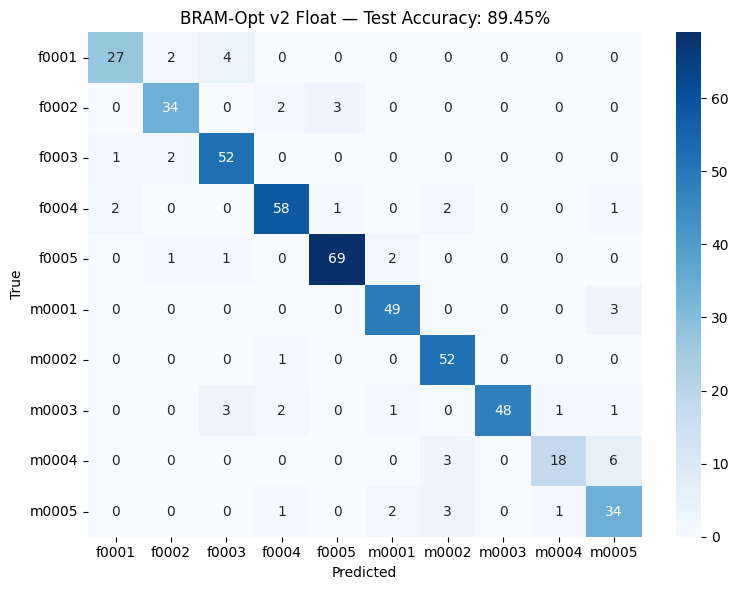

              precision    recall  f1-score   support

       f0001       0.90      0.82      0.86        33
       f0002       0.87      0.87      0.87        39
       f0003       0.87      0.95      0.90        55
       f0004       0.91      0.91      0.91        64
       f0005       0.95      0.95      0.95        73
       m0001       0.91      0.94      0.92        52
       m0002       0.87      0.98      0.92        53
       m0003       1.00      0.86      0.92        56
       m0004       0.90      0.67      0.77        27
       m0005       0.76      0.83      0.79        41

    accuracy                           0.89       493
   macro avg       0.89      0.88      0.88       493
weighted avg       0.90      0.89      0.89       493



In [20]:
# Confusion matrix on test set
all_preds, all_labels = [], []
for xb, yb in MFCC_dataset_test_batches:
    preds = model_compact_float.predict(xb, verbose=0).argmax(axis=1)
    all_preds.extend(preds)
    all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=subfolders, yticklabels=subfolders)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'BRAM-Opt v2 Float — Test Accuracy: {test_acc*100:.2f}%')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=subfolders))

---
## Summary

In [21]:
print('\n' + '=' * 56)
print(f'  BRAM-Opt v2 Float Model — Summary')
print('=' * 56)
print(f'  Architecture   : 3-block CNN, 8 filters, all layers <= 576 params')
print(f'  Input shape    : {MFCC_input_shape}')
print(f'  MFCC config    : hop={HOP_LENGTH}, frames={MFCC_FRAMES}, N_MFCC={N_MFCC}')
print(f'  Parameters     : {model_compact_float.count_params():,}')
print(f'  Training       : Adam LR=1e-3, ReduceLR(0.5/10), EarlyStop(20)')
print(f'  Max epochs     : {MAX_EPOCHS}')
print(f'  Val accuracy   : {val_acc*100:.2f}%')
print(f'  Test accuracy  : {test_acc*100:.2f}%')
print(f'  Checkpoint     : {COMPACT_CKPT_PATH}')
print('=' * 56)


  BRAM-Opt v2 Float Model — Summary
  Architecture   : 3-block CNN, 8 filters, all layers <= 576 params
  Input shape    : (20, 64, 2)
  MFCC config    : hop=2250, frames=64, N_MFCC=20
  Parameters     : 1,858
  Training       : Adam LR=1e-3, ReduceLR(0.5/10), EarlyStop(20)
  Max epochs     : 150
  Val accuracy   : 88.62%
  Test accuracy  : 89.45%
  Checkpoint     : ./ckpt_compact_float/compact_float_best.h5
